IEEE-CIS Fraud Detection - DecisionTree


## 0. Setup

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn mlflow
import os, gc, time, pickle, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.feature_selection import (mutual_info_classif, VarianceThreshold,
                                       SelectKBest, RFE)
from sklearn.inspection import permutation_importance

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 61.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 9.0 MB/s eta 0:00:00


In [4]:
!pip install dagshub
import dagshub
REPO_OWNER = "rkvit23"
REPO_NAME  = "ML-HW2"
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/rkvit23/ML-HW2.mlflow")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=91decf64-9d4d-4006-b7b7-9e0633bedfa0&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=0f8cdf6582e07b61465c5cdeea28f29eb753ade59e226c0a3d5728f41d1a22aa




Output()

Accessing as rkvit23

Initialized MLflow to track repo "rkvit23/ML-HW2"

Repository rkvit23/ML-HW2 initialized!

In [5]:
MODEL_TAG = 'DecisionTree'
MLFLOW_EXPERIMENT = 'DecisionTree_Training'
print('MLflow experiment:', MLFLOW_EXPERIMENT)

MLflow experiment: DecisionTree_Training


In [6]:

DATA_DIR = "/kaggle/input/competitions/ieee-fraud-detection/"           
SAMPLE_FRAC = 1.0        

def reduce_mem(df):
    """Downcast numeric dtypes - typical 50-70% memory saving."""
    start = df.memory_usage(deep=True).sum() / 1024**2
    for c in df.columns:
        col = df[c]
        if pd.api.types.is_integer_dtype(col):
            df[c] = pd.to_numeric(col, downcast="integer")
        elif pd.api.types.is_float_dtype(col):
            df[c] = pd.to_numeric(col, downcast="float")
    end = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  memory: {start:.1f} MB -> {end:.1f} MB  ({100*(start-end)/start:.1f}% saved)")
    return df

print("Loading transaction tables...")
train_tx = pd.read_csv(os.path.join(DATA_DIR, "train_transaction.csv"))
test_tx  = pd.read_csv(os.path.join(DATA_DIR, "test_transaction.csv"))
print("Loading identity tables...")
train_id = pd.read_csv(os.path.join(DATA_DIR, "train_identity.csv"))
test_id  = pd.read_csv(os.path.join(DATA_DIR, "test_identity.csv"))

# Test identity columns are named with '-' instead of '_' in the official files
test_id.columns = [c.replace('-', '_') for c in test_id.columns]

train = train_tx.merge(train_id, on="TransactionID", how="left")
test  = test_tx.merge(test_id,  on="TransactionID", how="left")
del train_tx, test_tx, train_id, test_id; gc.collect()

if SAMPLE_FRAC < 1.0:
    train = train.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)

train = reduce_mem(train)
test  = reduce_mem(test)

print(f"\nTrain shape: {train.shape}   |  fraud rate: {train['isFraud'].mean():.4f}")
print(f"Test  shape: {test.shape}")


Loading transaction tables...
Loading identity tables...
  memory: 2514.0 MB -> 1603.3 MB  (36.2% saved)
  memory: 2164.1 MB -> 1386.1 MB  (35.9% saved)

Train shape: (590540, 434)   |  fraud rate: 0.0350
Test  shape: (506691, 433)


Class distribution:
isFraud
0    0.96501
1    0.03499
Name: pct, dtype: float64


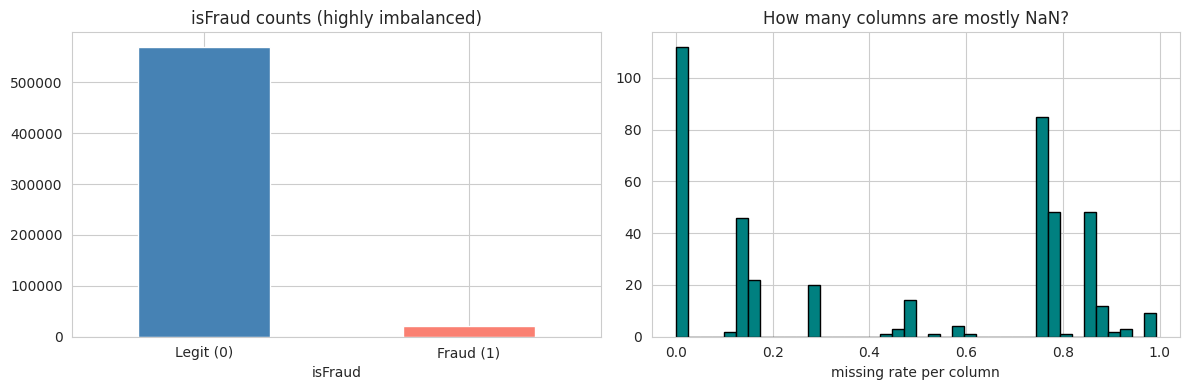


Columns with >50% missing values: 214  / 434
Columns with >90% missing values: 12


In [7]:
# Quick sanity check on class balance and missing rate.
print("Class distribution:")
print(train['isFraud'].value_counts(normalize=True).rename('pct'))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
train['isFraud'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue','salmon'])
ax[0].set_title('isFraud counts (highly imbalanced)')
ax[0].set_xticklabels(['Legit (0)','Fraud (1)'], rotation=0)

miss = train.isnull().mean().sort_values(ascending=False)
ax[1].hist(miss.values, bins=40, color='teal', edgecolor='black')
ax[1].set_xlabel('missing rate per column')
ax[1].set_title('How many columns are mostly NaN?')
plt.tight_layout(); plt.show()

print(f"\nColumns with >50% missing values: {(miss > 0.5).sum()}  / {train.shape[1]}")
print(f"Columns with >90% missing values: {(miss > 0.9).sum()}")


1. Cleaning



In [8]:
TARGET = "isFraud"
ID_COL = "TransactionID"

def analyse_missing(df, name):
    miss = df.isnull().mean().sort_values(ascending=False)
    almost_empty = miss[miss > 0.95].index.tolist()
    constant     = [c for c in df.columns
                    if df[c].nunique(dropna=False) <= 1]
    print(f"[{name}]  >95% NaN: {len(almost_empty)}   constant: {len(constant)}")
    return sorted(set(almost_empty + constant))

drop_train = analyse_missing(train, "train")
drop_test  = analyse_missing(test,  "test")
DROP_COLS = sorted(set(drop_train) | set(drop_test))
DROP_COLS = [c for c in DROP_COLS if c not in (TARGET, ID_COL)]

print(f"\nWill drop {len(DROP_COLS)} useless columns:")
print(DROP_COLS[:25], "...")

train.drop(columns=DROP_COLS, inplace=True, errors='ignore')
test.drop(columns=DROP_COLS,  inplace=True, errors='ignore')

print(f"\nAfter cleaning - train: {train.shape}, test: {test.shape}")
gc.collect()


[train]  >95% NaN: 9   constant: 0
[test]  >95% NaN: 9   constant: 1

Will drop 10 useless columns:
['V107', 'id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27'] ...

After cleaning - train: (590540, 424), test: (506691, 423)


20

. Feature Engineering



In [9]:
EMAIL_HIGH_RISK = {'protonmail.com','mail.com','outlook.es','aim.com',
                   'anonymous.com'}

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """All the engineered features (time, email, amount, aggregations)."""
    def __init__(self):
        self.card1_amt_mean_ = None
        self.card1_amt_std_  = None
        self.freq_maps_      = {}

    def fit(self, X, y=None):
        # Aggregations learned only on TRAIN
        if 'card1' in X.columns and 'TransactionAmt' in X.columns:
            g = X.groupby('card1')['TransactionAmt']
            self.card1_amt_mean_ = g.mean()
            self.card1_amt_std_  = g.std().fillna(0)
        for col in ['card1','card2','card3','card5','addr1','P_emaildomain',
                    'R_emaildomain']:
            if col in X.columns:
                self.freq_maps_[col] = X[col].value_counts(dropna=False)
        return self

    def transform(self, X):
        X = X.copy()
        # ---- time decomposition ----
        if 'TransactionDT' in X.columns:
            X['TX_hour']   = (X['TransactionDT'] // 3600) % 24
            X['TX_day']    = (X['TransactionDT'] // 86400)
            X['TX_dow']    = (X['TX_day'] % 7).astype('int8')
        # ---- amount features ----
        if 'TransactionAmt' in X.columns:
            X['TX_amt_log']     = np.log1p(X['TransactionAmt'])
            X['TX_amt_decimal'] = ((X['TransactionAmt'] -
                                    np.floor(X['TransactionAmt'])) * 1000).astype('int32')
        # ---- email features ----
        for col in ['P_emaildomain','R_emaildomain']:
            if col in X.columns:
                base = X[col].fillna('NA').astype(str)
                X[col + '_base'] = base.str.split('.').str[0]
                X[col + '_suf']  = base.str.split('.').str[-1]
                X[col + '_risk'] = base.isin(EMAIL_HIGH_RISK).astype('int8')
        # ---- card1 aggregations ----
        if self.card1_amt_mean_ is not None and 'card1' in X.columns:
            X['card1_amt_mean'] = X['card1'].map(self.card1_amt_mean_)
            X['card1_amt_std']  = X['card1'].map(self.card1_amt_std_)
            X['card1_amt_diff'] = X['TransactionAmt'] - X['card1_amt_mean']
        # ---- frequency encoding ----
        for col, fmap in self.freq_maps_.items():
            X[col + '_freq'] = X[col].map(fmap).fillna(0).astype('float32')
        return X


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """Label-encode every object column the same way for train+test.
    Unknown test categories -> -1 (sentinel)."""
    def __init__(self):
        self.maps_ = {}

    def fit(self, X, y=None):
        for c in X.columns:
            if X[c].dtype == 'object' or X[c].dtype.name == 'category':
                vals = X[c].astype(str).fillna('NA').unique()
                self.maps_[c] = {v: i for i, v in enumerate(vals)}
        return self

    def transform(self, X):
        X = X.copy()
        for c, m in self.maps_.items():
            if c in X.columns:
                X[c] = X[c].astype(str).fillna('NA').map(m).fillna(-1).astype('int32')
        return X


class Imputer(BaseEstimator, TransformerMixin):
    """Median imputation for numeric, -1 for categorical/encoded.
    Also clips +-inf to NaN first so downstream models never see a non-finite value."""
    def __init__(self):
        self.medians_ = None

    def fit(self, X, y=None):
        Xc = X.replace([np.inf, -np.inf], np.nan)
        self.medians_ = Xc.median(numeric_only=True)
        return self

    def transform(self, X):
        X = X.copy()
        # Inf -> NaN first (e.g. card1_amt_diff after float32 downcast)
        X = X.replace([np.inf, -np.inf], np.nan)
        for c in X.columns:
            if X[c].isnull().any():
                X[c] = X[c].fillna(self.medians_.get(c, -1))
        # any remaining NaN (e.g. all-NaN col, object col) -> -1
        return X.fillna(-1)


In [10]:
# Build raw matrices we will pass through the FE pipeline
y          = train[TARGET].values
X_train_raw = train.drop(columns=[TARGET, ID_COL])
X_test_raw  = test.drop(columns=[ID_COL])
print(f"Raw shapes: train {X_train_raw.shape}, test {X_test_raw.shape}")

fe_pipeline = Pipeline([
    ('feat',    FeatureEngineer()),
    ('catenc',  CategoricalEncoder()),
    ('impute',  Imputer()),
])

fe_pipeline.fit(X_train_raw, y)
X_train_fe = fe_pipeline.transform(X_train_raw)
X_test_fe  = fe_pipeline.transform(X_test_raw)
print(f"After FE  : train {X_train_fe.shape}, test {X_test_fe.shape}")

# Hard sanity: nothing non-finite reaches feature selection / models.
# (mutual_info_classif and VarianceThreshold both call check_array with
#  force_all_finite=True and will raise ValueError otherwise.)
def assert_finite(df, name):
    nans = int(df.isnull().sum().sum())
    infs = int(np.isinf(df.select_dtypes(include=[np.number]).values).sum())
    print(f"  [{name}] NaNs={nans}, Infs={infs}")
    if nans or infs:
        # belt-and-braces: replace and continue
        df.replace([np.inf, -np.inf], 0, inplace=True)
        df.fillna(0, inplace=True)
        print(f"  [{name}] -> cleaned to all-finite")
    return df

X_train_fe = assert_finite(X_train_fe, 'train_fe')
X_test_fe  = assert_finite(X_test_fe,  'test_fe')


Raw shapes: train (590540, 422), test (506691, 422)
After FE  : train (590540, 443), test (506691, 443)
  [train_fe] NaNs=0, Infs=0
  [test_fe] NaNs=0, Infs=0


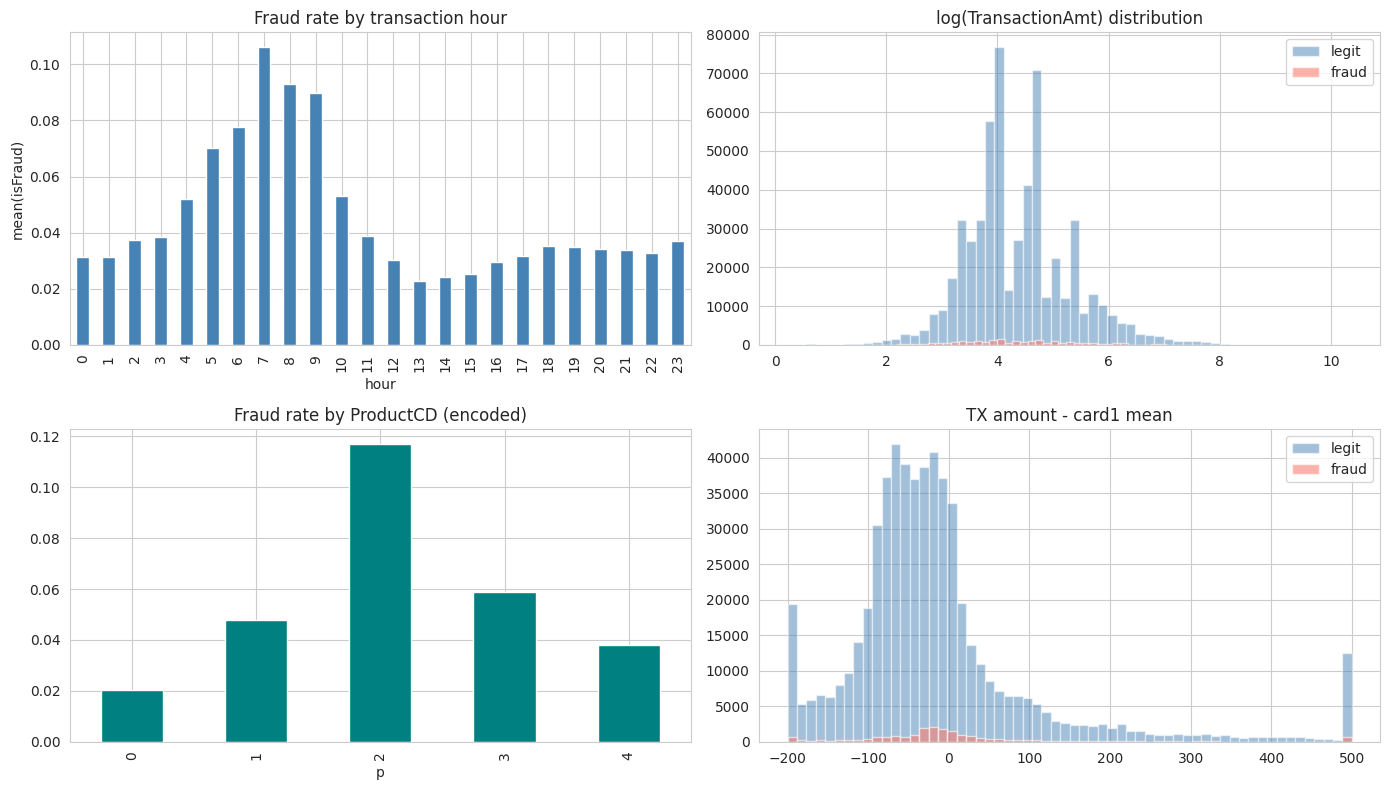

In [12]:
# Visualise a few engineered features vs target
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

# fraud rate by hour
hr = pd.DataFrame({'hour': X_train_fe['TX_hour'], 'fraud': y})
hr.groupby('hour')['fraud'].mean().plot(kind='bar', ax=ax[0,0], color='steelblue')
ax[0,0].set_title('Fraud rate by transaction hour')
ax[0,0].set_ylabel('mean(isFraud)')

# log amount distribution
ax[0,1].hist(X_train_fe.loc[y==0,'TX_amt_log'], bins=60, alpha=.5, label='legit', color='steelblue')
ax[0,1].hist(X_train_fe.loc[y==1,'TX_amt_log'], bins=60, alpha=.6, label='fraud', color='salmon')
ax[0,1].legend(); ax[0,1].set_title('log(TransactionAmt) distribution')

# fraud rate by ProductCD if encoded
if 'ProductCD' in X_train_fe.columns:
    pcd = pd.DataFrame({'p': X_train_fe['ProductCD'], 'fraud': y})
    pcd.groupby('p')['fraud'].mean().plot(kind='bar', ax=ax[1,0], color='teal')
    ax[1,0].set_title('Fraud rate by ProductCD (encoded)')

# card1_amt_diff for fraud vs legit
if 'card1_amt_diff' in X_train_fe.columns:
    ax[1,1].hist(X_train_fe.loc[y==0,'card1_amt_diff'].clip(-200,500), bins=60,
                 alpha=.5, label='legit', color='steelblue')
    ax[1,1].hist(X_train_fe.loc[y==1,'card1_amt_diff'].clip(-200,500), bins=60,
                 alpha=.6, label='fraud', color='salmon')
    ax[1,1].legend(); ax[1,1].set_title('TX amount - card1 mean')

plt.tight_layout(); plt.show()



3. Feature Selection




VarianceThreshold (constants out): kept 443


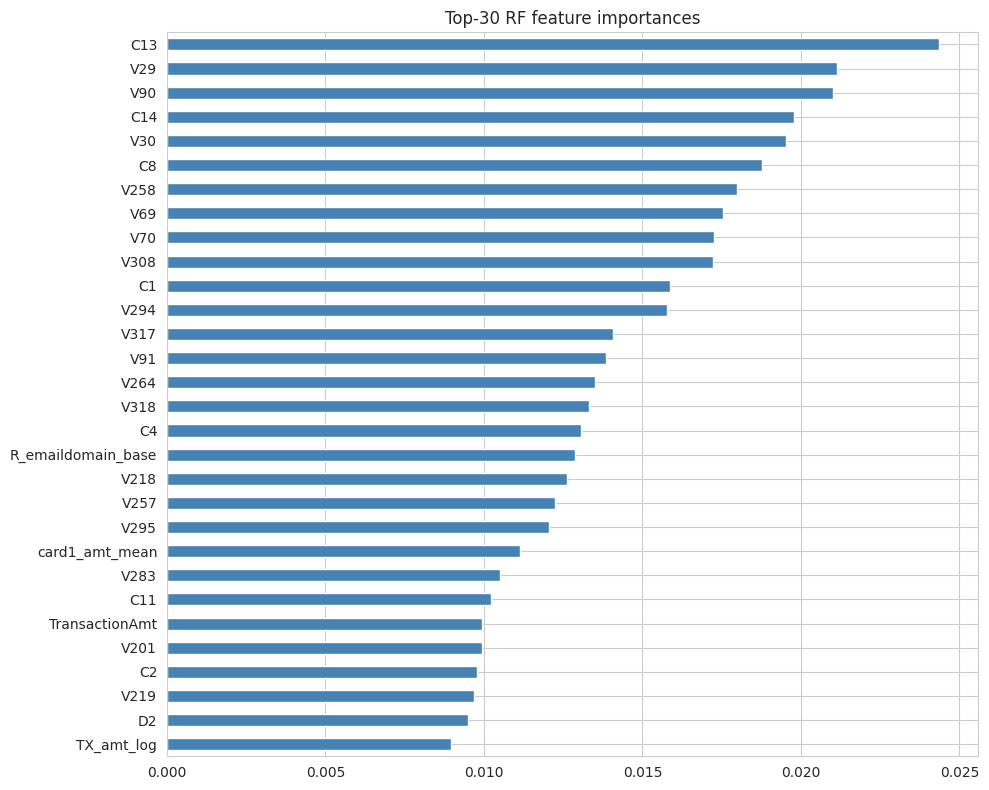

Permutation > 0.0001 -> 185 features
  all_after_VT         -> 443 features
  RF_top80             -> 80 features
  PermImp>0.0001       -> 185 features


In [13]:
from sklearn.ensemble import RandomForestClassifier as _QuickRF

# 3.1 Variance threshold
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_fe)
keep_vt = X_train_fe.columns[vt.get_support()].tolist()
print(f"VarianceThreshold (constants out): kept {len(keep_vt)}")

# 3.2 RF embedded importance (fit on a subsample for speed)
sample_idx = np.random.RandomState(SEED).choice(len(X_train_fe),
                                                size=min(80000, len(X_train_fe)),
                                                replace=False)
imp_rf = _QuickRF(n_estimators=120, max_depth=10, n_jobs=-1,
                  class_weight='balanced', random_state=SEED)
imp_rf.fit(X_train_fe[keep_vt].iloc[sample_idx], y[sample_idx])
imp_series = pd.Series(imp_rf.feature_importances_, index=keep_vt
                       ).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
imp_series.head(30).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis(); ax.set_title('Top-30 RF feature importances')
plt.tight_layout(); plt.show()

TOPK_RF = 80
keep_rf = imp_series.head(TOPK_RF).index.tolist()

# 3.3 Permutation importance on a smaller sample
perm_idx = np.random.RandomState(SEED).choice(len(X_train_fe),
                                              size=min(20000, len(X_train_fe)),
                                              replace=False)
perm_res = permutation_importance(imp_rf, X_train_fe[keep_vt].iloc[perm_idx],
                                  y[perm_idx], n_repeats=3, n_jobs=-1,
                                  random_state=SEED, scoring='roc_auc')
perm_series = pd.Series(perm_res.importances_mean, index=keep_vt
                        ).sort_values(ascending=False)
keep_perm = perm_series[perm_series > 0.0001].index.tolist()
print(f"Permutation > 0.0001 -> {len(keep_perm)} features")

FEATURE_SETS = {
    'all_after_VT'        : keep_vt,
    f'RF_top{TOPK_RF}'    : keep_rf,
    'PermImp>0.0001'      : keep_perm,
}
for name, cols in FEATURE_SETS.items():
    print(f"  {name:20s} -> {len(cols)} features")


  all_after_VT              |  443 feats | AUC = 0.87246 (+/- 0.00374)
  RF_top80                  |   80 feats | AUC = 0.87591 (+/- 0.00504)
  PermImp>0.0001            |  185 feats | AUC = 0.87626 (+/- 0.00391)

Best FS = PermImp>0.0001  (185 features)


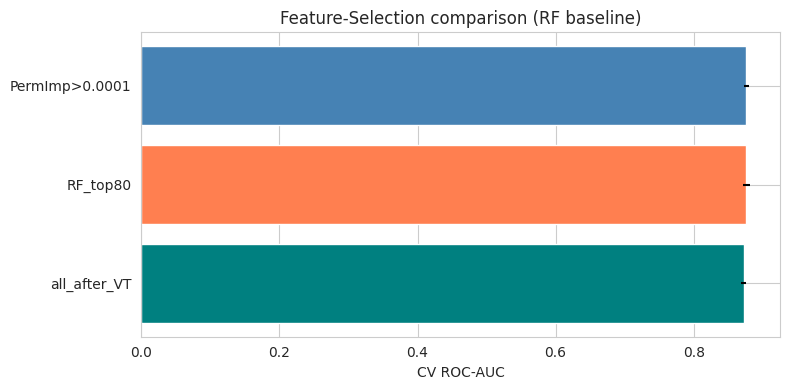

In [14]:
from sklearn.ensemble import RandomForestClassifier as _QuickRF
quick = _QuickRF(n_estimators=80, max_depth=8, n_jobs=-1,
                 class_weight='balanced', random_state=SEED)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
sample_idx = np.random.RandomState(SEED).choice(len(X_train_fe),
                                                size=min(60000, len(X_train_fe)),
                                                replace=False)

fs_results = []
for name, cols in FEATURE_SETS.items():
    Xs = X_train_fe[cols].iloc[sample_idx].values
    aucs = cross_val_score(quick, Xs, y[sample_idx], cv=cv,
                           scoring='roc_auc', n_jobs=-1)
    fs_results.append({'method': name, 'n_feat': len(cols),
                       'mean_auc': aucs.mean(), 'std_auc': aucs.std()})
    print(f"  {name:25s} | {len(cols):4d} feats | AUC = {aucs.mean():.5f} (+/- {aucs.std():.5f})")

fs_df = pd.DataFrame(fs_results).sort_values('mean_auc', ascending=False)
best_fs_name = fs_df.iloc[0]['method']
SELECTED_FEATURES = FEATURE_SETS[best_fs_name]
print(f"\nBest FS = {best_fs_name}  ({len(SELECTED_FEATURES)} features)")

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(fs_df['method'], fs_df['mean_auc'], xerr=fs_df['std_auc'],
        color=['steelblue','coral','teal'])
ax.set_xlabel('CV ROC-AUC'); ax.invert_yaxis()
ax.set_title('Feature-Selection comparison (RF baseline)')
plt.tight_layout(); plt.show()




4. Training - Decision Tree



In [15]:
def fit_eval(model, X_tr, y_tr, X_val, y_val, cv=None):
    """Train + return metrics dict (no MLflow side-effects)."""
    model.fit(X_tr, y_tr)
    if hasattr(model, "predict_proba"):
        p_tr  = model.predict_proba(X_tr)[:, 1]
        p_val = model.predict_proba(X_val)[:, 1]
    else:
        p_tr  = model.decision_function(X_tr)
        p_val = model.decision_function(X_val)
    pr_tr  = (p_tr  > 0.5).astype(int)
    pr_val = (p_val > 0.5).astype(int)
    metrics = {
        'train_auc'   : roc_auc_score(y_tr,  p_tr),
        'val_auc'     : roc_auc_score(y_val, p_val),
        'train_ap'    : average_precision_score(y_tr,  p_tr),
        'val_ap'      : average_precision_score(y_val, p_val),
        'val_f1'      : f1_score(y_val, pr_val, zero_division=0),
        'val_prec'    : precision_score(y_val, pr_val, zero_division=0),
        'val_recall'  : recall_score(y_val, pr_val, zero_division=0),
        'overfit_gap' : roc_auc_score(y_tr, p_tr) - roc_auc_score(y_val, p_val),
    }
    if cv is not None:
        cv_aucs = cross_val_score(model, X_tr, y_tr, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
        metrics['cv_auc_mean'] = cv_aucs.mean()
        metrics['cv_auc_std']  = cv_aucs.std()
    return metrics

def print_m(tag, m):
    print(f"  [{tag}]")
    for k, v in m.items():
        print(f"    {k:14s} = {v:.5f}")

results_log = []


In [16]:
from sklearn.tree import DecisionTreeClassifier

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_sel = X_train_fe[SELECTED_FEATURES].astype(np.float32).values
X_tr, X_val, y_tr, y_val = train_test_split(X_sel, y, test_size=0.2,
                                            stratify=y, random_state=SEED)
print(f"X_tr {X_tr.shape}, X_val {X_val.shape}")


X_tr (472432, 185), X_val (118108, 185)


In [17]:
m = DecisionTreeClassifier(max_depth=3,  random_state=SEED, class_weight='balanced')
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("depth=3 underfit", mt)
results_log.append({'name': "DT_depth=3 underfit", 'model': m, **mt})


  [depth=3 underfit]
    train_auc      = 0.77014
    val_auc        = 0.76855
    train_ap       = 0.21232
    val_ap         = 0.20731
    val_f1         = 0.20701
    val_prec       = 0.12277
    val_recall     = 0.65957
    overfit_gap    = 0.00159


In [18]:
m = DecisionTreeClassifier(max_depth=5,  random_state=SEED, class_weight='balanced')
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("depth=5", mt)
results_log.append({'name': "DT_depth=5", 'model': m, **mt})


  [depth=5]
    train_auc      = 0.81895
    val_auc        = 0.81776
    train_ap       = 0.27930
    val_ap         = 0.27694
    val_f1         = 0.22179
    val_prec       = 0.13058
    val_recall     = 0.73554
    overfit_gap    = 0.00119


In [19]:
m = DecisionTreeClassifier(max_depth=10, random_state=SEED, class_weight='balanced')
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("depth=10", mt)
results_log.append({'name': "DT_depth=10", 'model': m, **mt})


  [depth=10]
    train_auc      = 0.89552
    val_auc        = 0.86486
    train_ap       = 0.44939
    val_ap         = 0.41150
    val_f1         = 0.27817
    val_prec       = 0.17159
    val_recall     = 0.73433
    overfit_gap    = 0.03065


In [20]:
m = DecisionTreeClassifier(max_depth=15, random_state=SEED, class_weight='balanced')
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("depth=15", mt)
results_log.append({'name': "DT_depth=15", 'model': m, **mt})


  [depth=15]
    train_auc      = 0.95123
    val_auc        = 0.84682
    train_ap       = 0.60758
    val_ap         = 0.44899
    val_f1         = 0.33792
    val_prec       = 0.21839
    val_recall     = 0.74643
    overfit_gap    = 0.10441


In [21]:
m = DecisionTreeClassifier(max_depth=None, random_state=SEED, class_weight='balanced')
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("depth=None overfit", mt)
results_log.append({'name': "DT_depth=None overfit", 'model': m, **mt})


  [depth=None overfit]
    train_auc      = 1.00000
    val_auc        = 0.77052
    train_ap       = 1.00000
    val_ap         = 0.32126
    val_f1         = 0.55296
    val_prec       = 0.54829
    val_recall     = 0.55771
    overfit_gap    = 0.22948


In [22]:
m = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=SEED, class_weight='balanced')
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("depth=10 + min_leaf=20", mt)
results_log.append({'name': "DT_depth=10 + min_leaf=20", 'model': m, **mt})


  [depth=10 + min_leaf=20]
    train_auc      = 0.89445
    val_auc        = 0.86650
    train_ap       = 0.45190
    val_ap         = 0.42229
    val_f1         = 0.27526
    val_prec       = 0.16919
    val_recall     = 0.73772
    overfit_gap    = 0.02795


In [23]:
m = DecisionTreeClassifier(max_depth=10, min_samples_split=50, random_state=SEED, class_weight='balanced')
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("depth=10 + min_split=50", mt)
results_log.append({'name': "DT_depth=10 + min_split=50", 'model': m, **mt})


  [depth=10 + min_split=50]
    train_auc      = 0.89480
    val_auc        = 0.86588
    train_ap       = 0.44333
    val_ap         = 0.41492
    val_f1         = 0.27680
    val_prec       = 0.17045
    val_recall     = 0.73603
    overfit_gap    = 0.02892


In [24]:
m = DecisionTreeClassifier(max_depth=10, criterion='entropy', random_state=SEED, class_weight='balanced')
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("entropy criterion", mt)
results_log.append({'name': "DT_entropy criterion", 'model': m, **mt})


  [entropy criterion]
    train_auc      = 0.89777
    val_auc        = 0.87247
    train_ap       = 0.51544
    val_ap         = 0.46505
    val_f1         = 0.23286
    val_prec       = 0.13677
    val_recall     = 0.78297
    overfit_gap    = 0.02530


                      name  train_auc  val_auc   val_f1   val_ap  overfit_gap    diagnosis
      DT_entropy criterion   0.897773 0.872468 0.232864 0.465048     0.025305 mild-overfit
 DT_depth=10 + min_leaf=20   0.894445 0.866499 0.275255 0.422287     0.027947 mild-overfit
DT_depth=10 + min_split=50   0.894799 0.865879 0.276797 0.414921     0.028920 mild-overfit
               DT_depth=10   0.895519 0.864865 0.278172 0.411502     0.030654 mild-overfit
               DT_depth=15   0.951226 0.846819 0.337916 0.448992     0.104407      OVERFIT
                DT_depth=5   0.818953 0.817764 0.221793 0.276941     0.001189           ok
     DT_depth=None overfit   1.000000 0.770522 0.552957 0.321261     0.229478      OVERFIT
       DT_depth=3 underfit   0.770140 0.768548 0.207009 0.207315     0.001592           ok


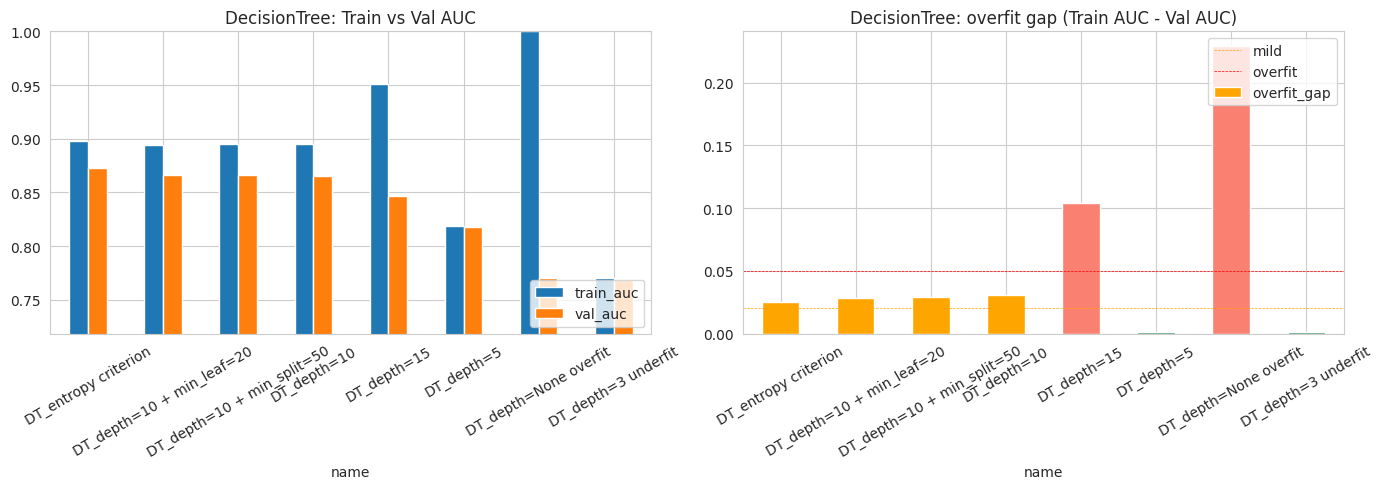

-> picked best_model = DT_entropy criterion


In [25]:
df_results = pd.DataFrame([{k:v for k,v in r.items() if k!='model'} for r in results_log])
df_results = df_results.sort_values('val_auc', ascending=False).reset_index(drop=True)

def _diag(row):
    if row['train_auc'] < 0.75:
        return 'UNDERFIT'
    if row['overfit_gap'] > 0.05:
        return 'OVERFIT'
    if row['overfit_gap'] < 0:
        return 'lucky-val'
    if row['val_auc'] >= 0.85 and row['overfit_gap'] <= 0.02:
        return 'HEALTHY'
    return 'mild-overfit' if row['overfit_gap'] > 0.02 else 'ok'
df_results['diagnosis'] = df_results.apply(_diag, axis=1)

_default_cols = ['name','train_auc','val_auc','val_f1','val_ap','overfit_gap','diagnosis']
show_cols = [c for c in _default_cols if c in df_results.columns]
print(df_results[show_cols].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df_results.set_index('name')[['train_auc','val_auc']].plot(kind='bar', ax=ax[0])
ax[0].set_title('DecisionTree: Train vs Val AUC')
ax[0].set_ylim(max(0.5, df_results[['train_auc','val_auc']].min().min()-0.05), 1.0)
ax[0].tick_params(axis='x', rotation=30); ax[0].legend(loc='lower right')

colors = ['salmon' if g > 0.05 else ('orange' if g > 0.02 else 'seagreen')
          for g in df_results['overfit_gap']]
df_results.set_index('name')['overfit_gap'].plot(kind='bar', ax=ax[1], color=colors)
ax[1].axhline(0,    color='black', lw=0.5)
ax[1].axhline(0.02, color='orange', ls='--', lw=0.5, label='mild')
ax[1].axhline(0.05, color='red',    ls='--', lw=0.5, label='overfit')
ax[1].set_title('DecisionTree: overfit gap (Train AUC - Val AUC)')
ax[1].tick_params(axis='x', rotation=30); ax[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

n_over   = int((df_results['diagnosis']=='OVERFIT').sum())
n_under  = int((df_results['diagnosis']=='UNDERFIT').sum())
n_health = int((df_results['diagnosis']=='HEALTHY').sum())
best     = df_results.iloc[0]
worst    = df_results.iloc[-1]


best_model = [r['model'] for r in results_log if r['name']==best['name']][0]
print(f"-> picked best_model = {best['name']}")


## 5. Pipeline Construction & Save

We bundle the whole preprocessing chain and the best trained model into one
sklearn `Pipeline` that can be applied **directly to the raw test CSVs** -
no separate preprocessing step required at inference time. The pipeline is
saved both as a local pickle and as an MLflow artifact (next section).


In [26]:
import pickle
from sklearn.pipeline import Pipeline

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X[self.cols]

# Build a single pipeline that runs on RAW test data
final_pipeline = Pipeline([
    ('feat',   FeatureEngineer()),
    ('catenc', CategoricalEncoder()),
    ('impute', Imputer()),
    ('select', ColumnSelector(SELECTED_FEATURES)),
    ('model',  best_model),
])

# Refit FE part + best model on the FULL training data (raw)
final_pipeline.fit(X_train_raw, y)
print("Pipeline fitted on full raw training data.")

# Sanity: probabilistic predictions on raw test
test_pred_proba = final_pipeline.predict_proba(X_test_raw)[:, 1]
print(f"Test prediction probabilities sample: {test_pred_proba[:5]}")
print(f"Mean predicted P(fraud) on test set : {test_pred_proba.mean():.4f}")

# Save pipeline locally too (optional)
PIPE_PATH = f"pipeline_{MODEL_TAG}.pkl"
with open(PIPE_PATH, 'wb') as f:
    pickle.dump(final_pipeline, f)
print(f"Pipeline saved to {PIPE_PATH}")


Pipeline fitted on full raw training data.
Test prediction probabilities sample: [0.42808128 0.2543153  0.2543153  0.         0.04199215]
Mean predicted P(fraud) on test set : 0.2915
Pipeline saved to pipeline_DecisionTree.pkl


6. MLflow Logging


In [30]:
# 6.3  Cleaning summary run
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Cleaning"):
    mlflow.log_param('stage', 'cleaning')
    mlflow.log_param('dropped_columns', len(DROP_COLS))
    mlflow.log_param('train_shape_after', str(train.shape))
    mlflow.log_param('test_shape_after',  str(test.shape))
print("Cleaning run logged.")


🏃 View run DecisionTree_Cleaning at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/1fa82994daf441698a1afb9cc9c4302b
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4
Cleaning run logged.


In [29]:
# 6.2  Feature-Selection comparison run
mlflow.set_experiment(MLFLOW_EXPERIMENT)

import re
def _safe(s):
    # MLflow allows only [A-Za-z0-9_.\-: /] in metric / param keys.
    return re.sub(r'[^A-Za-z0-9_.\-: /]', '_', str(s))

with mlflow.start_run(run_name=f"{MODEL_TAG}_Feature_Selection"):
    mlflow.log_param('stage',     'feature_selection')
    mlflow.log_param('chosen',    best_fs_name if 'best_fs_name' in dir() else 'n/a')
    mlflow.log_param('n_selected', len(SELECTED_FEATURES))
    if 'fs_df' in dir():
        for _, row in fs_df.iterrows():
            mlflow.log_metric(f"AUC_{_safe(row['method'])}", float(row['mean_auc']))
print("Feature Selection run logged.")

🏃 View run DecisionTree_Feature_Selection at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/9cd01502acf149a78f594c2ba698f5b4
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4
Feature Selection run logged.


In [31]:
# 6.3.5  Feature Engineering summary run
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Feature_Engineering"):
    mlflow.log_param('stage', 'feature_engineering')
    mlflow.log_param('n_input_cols',  X_train_raw.shape[1])
    mlflow.log_param('n_output_cols', X_train_fe.shape[1])
    mlflow.log_param('n_added',       X_train_fe.shape[1] - X_train_raw.shape[1])

    # Engineered feature groups (from the FeatureEngineer transformer)
    fe_groups = {
        'time'    : [c for c in X_train_fe.columns if c.startswith('TX_hour') or c.startswith('TX_day') or c.startswith('TX_dow')],
        'amount'  : [c for c in X_train_fe.columns if c.startswith('TX_amt_')],
        'email'   : [c for c in X_train_fe.columns if c.endswith('_base') or c.endswith('_suf') or c.endswith('_risk')],
        'card_agg': [c for c in X_train_fe.columns if c.startswith('card1_amt')],
        'freq'    : [c for c in X_train_fe.columns if c.endswith('_freq')],
    }
    for grp, cols in fe_groups.items():
        mlflow.log_param(f'fe_{grp}_count', len(cols))
        mlflow.log_param(f'fe_{grp}_sample', ', '.join(cols[:5]))
    mlflow.log_param('transformers', 'FeatureEngineer + CategoricalEncoder + Imputer')
print("Feature Engineering run logged.")

🏃 View run DecisionTree_Feature_Engineering at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/fc0a1a1481764c10b0175013b0950a9d
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4
Feature Engineering run logged.


In [27]:
# 6.1  Per-hyperparameter runs
mlflow.set_experiment(MLFLOW_EXPERIMENT)

for r in results_log:
    with mlflow.start_run(run_name=r['name']):
        # Params (model + general)
        mlflow.log_param('model_type',        MODEL_TAG)
        mlflow.log_param('n_features',        len(SELECTED_FEATURES))
        mlflow.log_param('feature_selection', best_fs_name if 'best_fs_name' in dir() else 'manual')
        mlflow.log_param('config',            r['name'])
        # Metrics
        for k, v in r.items():
            if k in ('name','model'): continue
            try: mlflow.log_metric(k, float(v))
            except Exception: pass
print("Logged all training runs to MLflow.")


2026/05/04 05:36:25 INFO mlflow.tracking.fluent: Experiment with name 'DecisionTree_Training' does not exist. Creating a new experiment.


🏃 View run DT_depth=3 underfit at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/4dd89287111444d4bc3c1acd322554b7
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4
🏃 View run DT_depth=5 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/cec2bd7abbdf4012884ae1446916101d
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4
🏃 View run DT_depth=10 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/b024251b0a844a628a413bc5ea59c3c6
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4
🏃 View run DT_depth=15 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/fcfeac65d80749aeb8c1f1cf4df59f81
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4
🏃 View run DT_depth=None overfit at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/a5bd769a2b65483fb56adda8f9b74e01
🧪 View experiment at: https://dagshub.com/rkvit2

In [32]:
# 6.4  Cross-validation run for the BEST hyperparameter set
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print("Re-running 5-fold CV for the BEST config (this can take a few min)...")
cv5_aucs = cross_val_score(best_model, X_train_fe[SELECTED_FEATURES].values, y,
                           cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                           scoring='roc_auc', n_jobs=-1)
print(f"CV AUC mean = {cv5_aucs.mean():.5f} +/- {cv5_aucs.std():.5f}")

with mlflow.start_run(run_name=f"{MODEL_TAG}_CrossValidation"):
    mlflow.log_param('stage', 'cross_validation')
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('best_config', best['name'])
    mlflow.log_metric('cv_auc_mean', float(cv5_aucs.mean()))
    mlflow.log_metric('cv_auc_std',  float(cv5_aucs.std()))
    for i, a in enumerate(cv5_aucs):
        mlflow.log_metric(f'cv_auc_fold{i+1}', float(a))
print("Cross-validation run logged.")


Re-running 5-fold CV for the BEST config (this can take a few min)...
CV AUC mean = 0.86622 +/- 0.00479
🏃 View run DecisionTree_CrossValidation at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/65b5efd4a778483880df9c48ce9b9da7
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4
Cross-validation run logged.


In [33]:
# 6.5  FINAL run -- log the trained Pipeline as MLflow artifact
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Final_Pipeline"):
    mlflow.log_param('model_type',        MODEL_TAG)
    mlflow.log_param('best_config',       best['name'])
    mlflow.log_param('n_features',        len(SELECTED_FEATURES))
    mlflow.log_param('feature_selection', best_fs_name if 'best_fs_name' in dir() else 'manual')

    mlflow.log_metric('best_val_auc',     float(best['val_auc']))
    mlflow.log_metric('best_train_auc',   float(best['train_auc']))
    mlflow.log_metric('best_overfit_gap', float(best['overfit_gap']))
    if 'cv5_aucs' in dir():
        mlflow.log_metric('cv_auc_mean', float(cv5_aucs.mean()))

    # Log entire pipeline (preprocessing + model) as an MLflow sklearn model
    # so model_inference can load it from the registry directly.
    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path='model',
        registered_model_name=f'IEEE_Fraud_{MODEL_TAG}',
    )

print(f"Final pipeline logged & registered as 'IEEE_Fraud_{MODEL_TAG}'.")
print("In model_inference.ipynb you can now load it via:")
print(f"    mlflow.sklearn.load_model('models:/IEEE_Fraud_{MODEL_TAG}/latest')")


2026/05/04 05:46:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 05:46:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'IEEE_Fraud_DecisionTree'.
2026/05/04 05:47:13 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: IEEE_Fraud_DecisionTree, version 1
Created version '1' of model 'IEEE_Fraud_DecisionTree'.


🏃 View run DecisionTree_Final_Pipeline at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4/runs/fd00f9f110594522974bca8b7714cc31
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/4
Final pipeline logged & registered as 'IEEE_Fraud_DecisionTree'.
In model_inference.ipynb you can now load it via:
    mlflow.sklearn.load_model('models:/IEEE_Fraud_DecisionTree/latest')
